In [1]:
import openeo
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd


# Connessione all'istanza OpenEO
connection = openeo.connect("openeo.dataspace.copernicus.eu")  # esempio, cambia con il tuo endpoint
# Autenticazione
connection.authenticate_oidc()
spatial_extent = {"type":"Polygon","coordinates":[[[14.140778,40.793019],[14.140778,40.915848],[14.348488,40.915848],[14.348488,40.793019],[14.140778,40.793019]]]}


Authenticated using refresh token.


In [2]:
connection.list_collections()

[{'description': 'Copernicus Global 30 meter Digital Elevation Model dataset.',
  'extent': {'spatial': {'bbox': [[-180, -90, 180, 90]]},
   'temporal': {'interval': [['2010-12-12T00:00:00Z',
      '2015-01-16T00:00:00Z']]}},
  'id': 'COPERNICUS_30',
  'keywords': ['Copernicus', 'ESA', 'Satellite', 'Global', 'DEM', 'EU', 'EC'],
  'license': 'proprietary',
  'links': [{'href': 'https://stac.dataspace.copernicus.eu/v1/collections/cop-dem-glo-30-dged-cog/items',
    'rel': 'items',
    'type': 'application/geo+json'},
   {'href': 'https://stac.dataspace.copernicus.eu/v1/',
    'rel': 'parent',
    'type': 'application/json'},
   {'href': 'https://stac.dataspace.copernicus.eu/v1/',
    'rel': 'root',
    'type': 'application/json'},
   {'href': 'https://stac.dataspace.copernicus.eu/v1/collections/cop-dem-glo-30-dged-cog',
    'rel': 'self',
    'type': 'application/json'},
   {'href': 'https://dataspace.copernicus.eu/sites/default/files/media/files/2025-06/copernicus_contributing_mission_data_access_v2_cop_dem_licenses.pdf',
    'rel': 'license',
    'title': 'Legal notice on the use of Copernicus DEM Data and Service Information',
    'type': 'application/pdf'},
   {'href': 'https://stac.dataspace.copernicus.eu/v1/collections/cop-dem-glo-30-dged-cog/queryables',
    'rel': 'http://www.opengis.net/def/rel/ogc/1.0/queryables',
    'title': 'Queryables',
    'type': 'application/schema+json'}],
  'providers': [{'name': 'ESA',
    'roles': ['producer'],
    'url': 'https://dataspace.copernicus.eu/explore-data/data-collections/copernicus-contributing-missions/collections-description/COP-DEM'},
   {'name': 'European Commission',
    'roles': ['licensor'],
    'url': 'https://commission.europa.eu/'},
   {'name': 'CloudFerro',
    'roles': ['host', 'processor'],
    'url': 'https://cloudferro.com/'}],
  'stac_extensions': ['https://stac-extensions.github.io/alternate-assets/v1.2.0/schema.json',
   'https://stac-extensions.github.io/authentication/v1.1.0/schema.json',
   'https://stac-extensions.github.io/processing/v1.2.0/schema.json',
   'https://stac-extensions.github.io/projection/v2.0.0/schema.json',
   'https://stac-extensions.github.io/sat/v1.1.0/schema.json',
   'https://stac-extensions.github.io/scientific/v1.0.0/schema.json',
   'https://stac-extensions.github.io/storage/v2.0.0/schema.json'],
  'stac_version': '1.1.0',
  'title': 'Copernicus Global 30 meter Digital Elevation Model dataset.'},
 {'description': 'Sentinel 3 imagery captured by OLCI sensor',
  'extent': {'spatial': {'bbox': [[-180.0, -85.0, 180.0, 85.0]]},
   'temporal': {'interval': [['2016-04-17T11:33:13Z', None]]}},
  'id': 'SENTINEL3_OLCI_L1B',
  'license': 'proprietary',
  'links': [{'href': 'https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/',
    'rel': 'root',
    'type': 'application/json'},
   {'href': 'https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/collections/sentinel-3-olci',
    'rel': 'self',
    'type': 'application/json'},
   {'href': 'https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/collections',
    'rel': 'parent',
    'type': 'application/json'},
   {'href': 'https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/collections/sentinel-3-olci/queryables',
    'rel': 'http://www.opengis.net/def/rel/ogc/1.0/queryables',
    'type': 'application/schema+json'},
   {'href': 'https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/collections/sentinel-3-olci/items',
    'rel': 'items',
    'type': 'application/geo+json'}],
  'providers': [],
  'stac_extensions': ['https://stac-extensions.github.io/scientific/v1.0.0/schema.json',
   'https://stac-extensions.github.io/sat/v1.0.0/schema.json',
   'https://stac-extensions.github.io/eo/v1.0.0/schema.json'],
  'stac_version': '1.0.0',
  'title': 'Sentinel 3 OLCI'},
 {'description': 'Sentinel 3 imagery captured by SLSTR sensor',
  'extent': {'spatial': {'bbox': [[-180.0, -85.0, 180.0, 85.0]]},
   'temporal': {'interval': [['2016-04-17T11:33:13Z', None]]}},
  'id': 'SENTINEL3_SLSTR',
  'l

In [3]:
s3cube = connection.load_collection(
    "SENTINEL3_SLSTR_L2_LST",
    spatial_extent = spatial_extent  ,
    temporal_extent=["2025-06-26", "2025-07-01"],  # esempio: mese di luglio 2025
    bands=["LST"]  
)

#mean_lst = s3cube.reduce_dimension(dimension="t", reducer="mean")

# Esegue il processo
s3cube.execute_batch("land_surface_temperature.nc",title="land_surface_temperature")


0:00:00 Job 'j-2603182040564113b6b847d481596da2': send 'start'
0:00:13 Job 'j-2603182040564113b6b847d481596da2': queued (progress 0%)
0:00:18 Job 'j-2603182040564113b6b847d481596da2': queued (progress 0%)
0:00:25 Job 'j-2603182040564113b6b847d481596da2': queued (progress 0%)
0:00:33 Job 'j-2603182040564113b6b847d481596da2': queued (progress 0%)
0:00:43 Job 'j-2603182040564113b6b847d481596da2': queued (progress 0%)
0:00:55 Job 'j-2603182040564113b6b847d481596da2': queued (progress 0%)
0:01:11 Job 'j-2603182040564113b6b847d481596da2': queued (progress 0%)
0:01:30 Job 'j-2603182040564113b6b847d481596da2': running (progress N/A)
0:01:54 Job 'j-2603182040564113b6b847d481596da2': running (progress N/A)
0:02:24 Job 'j-2603182040564113b6b847d481596da2': finished (progress 100%)


<BatchJob job_id='j-2603182040564113b6b847d481596da2'>

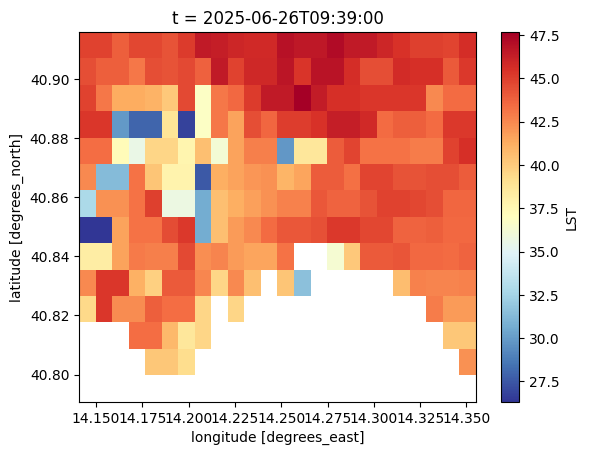

In [13]:

import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd

municipalities = gpd.read_file("municipalita.geojson")  # Carica il GeoDataFrame delle municipalità

# Carica il file NetCDF
ds = xr.open_dataset("land_surface_temperature.nc")
# Visualizza le variabili disponibili
LST = ds.isel(t=1).LST
LST = LST - 273.15  # Converti da Kelvin a Celsius
LST.plot(cmap='RdYlBu_r')  # Visualizza la prima immagine LST


In [ ]:

# I gradi della variabili LST sono in Kelvin, quindi convertiamo in Celsius
ds['LST'] = ds['LST'] - 273.15  # Conversione da Kelvin a Celsius   
# Plotta la mappa della temperatura superficiale terrestre e la mappa delle municipalità sovrapposta

fig, ax = plt.subplots(figsize=(20, 15))
ds.LST.plot(ax=ax, cmap='RdYlBu_r')  # oppure cmap='RdYlBu'
municipalities.boundary.plot(ax=ax, color='black', linewidth=1)  # Sovrappone i confini delle municipalità
ax.set_title("Temperatura Superficiale Terrestre con Confini delle Municipalità [26 Giugno 2025 - 1 Luglio 2025]")
ax.set_xlabel("Longitudine")
ax.set_ylabel("Latitudine")
plt.show()


In [15]:
LST.rio.to_raster("land_surface_temperature_s3_20250626T093900.tif")  # Salva come GeoTIFF

# LST - Planetary Computer

In [1]:
import pystac
import planetary_computer
import rioxarray

item_url = "https://planetarycomputer.microsoft.com/api/stac/v1/collections/landsat-c2-l2/items/LC09_L2SP_190031_20250627_02_T1"

# Load the individual item metadata and sign the assets
item = pystac.Item.from_file(item_url)

signed_item = planetary_computer.sign(item)

# Open one of the data assets (other asset keys to use: 'red', 'blue', 'drad', 'emis', 'emsd', 'trad', 'urad', 'atran', 'cdist', 'green', 'nir08', 'lwir11', 'swir16', 'swir22', 'coastal', 'qa_pixel', 'qa_radsat', 'qa_aerosol')
asset_href = signed_item.assets["lwir11"].href
lwir11 = rioxarray.open_rasterio(asset_href)
asset_href = signed_item.assets["emis"].href
emis = rioxarray.open_rasterio(asset_href)



In [2]:
lwir11_kelvin =( (lwir11 *0.00341802)+149.0)
lwir11_celsius =lwir11_kelvin-273.15
lwir11_celsius.rio.to_raster("lwir11_celsius.tif")



In [11]:
import numpy as np

# Costanti
lambda_ = 10.9e-6  # 10.9 micrometri
rho = 1.4388e-2    # m*K

# Dati
toa_kelvin = 310   # Temperatura di brillanza (Kelvin)
epsilon = 0.95    # Emissività

# Calcola LST
lst_kelvin = toa_kelvin / (1 + (lambda_ * toa_kelvin / rho) * np.log(epsilon))
lst_celsius = lst_kelvin - 273.15

print(f"LST: {lst_celsius:.2f} °C")


LST: 40.63 °C
